# 🕵️ Agentic Fake News Detection System
## Powered by DistilBERT + Three Collaborative AI Agents

---

## 📋 HOW TO RUN THIS NOTEBOOK (Read First!)

### Step 1 — Open in Google Colab
- Go to [colab.research.google.com](https://colab.research.google.com)
- Upload this `.ipynb` file via **File → Upload notebook**

### Step 2 — Enable GPU (Important for speed!)
- Click **Runtime → Change runtime type**
- Set **Hardware accelerator** to **T4 GPU**
- Click Save

### Step 3 — Upload your dataset files
- In the left sidebar, click the **folder icon** 📁
- Click the **upload icon** ⬆️
- Upload both **`Fake.csv`** and **`True.csv`**
- They should appear in `/content/Fake.csv` and `/content/True.csv`

### Step 4 — Run all cells
- Click **Runtime → Run all**  
- OR press `Ctrl+F9`
- The full pipeline takes ~15–25 minutes on GPU

### ✅ Expected Outputs
| Stage | What you'll see |
|---|---|
| Setup | ✅ green checkmarks for each library |
| Data Loading | Dataset shape, label counts, sample rows |
| Training | Loss and accuracy per epoch |
| Evaluation | Accuracy, F1-score, confusion matrix chart |
| Agent Demo | 3–5 articles analysed with verdicts + confidence scores |

### 🧪 Example Inputs to Test
Paste these into the demo cell at the bottom:
```
test_article_1 = "Scientists confirm new vaccine is 100% effective with zero side effects"
test_article_2 = "Senate passes bipartisan infrastructure bill after months of negotiation"
test_article_3 = "BREAKING: Celebrity admits to secret government mind control program"
```

---

## 🏗️ System Architecture

```
           Your Article (text input)
                     │
                     ▼
         ┌───────────────────────┐
         │    ANALYSIS AGENT     │  ← Looks at writing style, word choice,
         │                       │    emotional language, and credibility cues
         └───────────┬───────────┘
                     │
                     ▼
         ┌───────────────────────┐
         │  DISTILBERT MODEL     │  ← AI model trained on 44,000 real articles
         │  (Deep Learning)      │    gives a FAKE or REAL probability
         └───────────┬───────────┘
                     │
                     ▼
         ┌───────────────────────┐
         │  VERIFICATION AGENT   │  ← Double-checks the model's answer using
         │                       │    language rules and credibility signals
         └───────────┬───────────┘
                     │
                     ▼
         ┌───────────────────────┐
         │   DECISION AGENT      │  ← Combines everything into a final verdict
         │   (Orchestrator)      │    with a confidence score and explanation
         └───────────┬───────────┘
                     │
                     ▼
         ✅ REAL NEWS  or  ❌ FAKE NEWS
         (with confidence % and reasoning)
```

---

## 📦 SECTION 1: Install Libraries & Import Packages

In [1]:
# ============================================================
# CELL 1: Install Required Libraries
# This installs everything we need. Run this first.
# It may take 1-2 minutes.
# ============================================================

import subprocess, sys

def install_package(package_name):
    """Quietly installs a Python package."""
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name, '-q'])

# List of everything we need
required_packages = [
    'torch',           # Deep learning framework
    'transformers',    # Hugging Face: gives us DistilBERT
    'scikit-learn',    # Accuracy, F1-score, confusion matrix
    'pandas',          # Loading and handling CSV files
    'numpy',           # Number arrays and math
    'matplotlib',      # Drawing charts
    'seaborn',         # Pretty charts (used for confusion matrix)
    'tqdm',            # Progress bars during training
]

print('📦 Installing required libraries...')
print('=' * 45)

for pkg in required_packages:
    try:
        install_package(pkg)
        print(f'  ✅ {pkg}')
    except Exception as e:
        print(f'  ❌ {pkg} — failed: {e}')

print('=' * 45)
print('🎉 All libraries installed!')

📦 Installing required libraries...
  ✅ torch
  ✅ transformers
  ✅ scikit-learn
  ✅ pandas
  ✅ numpy
  ✅ matplotlib
  ✅ seaborn
  ✅ tqdm
🎉 All libraries installed!


In [2]:
# ============================================================
# CELL 2: Import Everything We Need
# After installing, we now import the libraries into memory.
# ============================================================

import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    DistilBertTokenizerFast,   # Converts text → numbers DistilBERT understands
    DistilBertForSequenceClassification,  # The DistilBERT model itself
    get_linear_schedule_with_warmup       # Learning rate scheduler
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tqdm import tqdm   # Shows a progress bar during training

warnings.filterwarnings('ignore')  # Keep output clean

# ── Detect GPU or CPU ──
# GPU is much faster; if you enabled it in Colab settings, it'll show here
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
else:
    print('   ⚠️  No GPU found. Training will be slower on CPU.')
    print('   Tip: Runtime → Change runtime type → T4 GPU')

print('\n✅ All imports successful!')

🖥️  Using device: cuda
   GPU: Tesla T4

✅ All imports successful!


---
## 📂 SECTION 2: Load & Explore the Dataset

We have two CSV files:
- **`Fake.csv`** — 23,481 fake news articles
- **`True.csv`** — 21,417 real news articles

We load both, add a `label` column (0 = Real, 1 = Fake), and combine them.

In [3]:
# ============================================================
# CELL 3: Load the Dataset
# We load Fake.csv and True.csv, then merge them into one
# big table with a 'label' column telling us which is which.
# ============================================================

# ── File paths ──
# In Google Colab, uploaded files go to /content/
FAKE_PATH = '/content/Fake.csv'
TRUE_PATH  = '/content/True.csv'

# ── Safety check: make sure files exist ──
for path in [FAKE_PATH, TRUE_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'\n❌ File not found: {path}\n'
            f'   Please upload Fake.csv and True.csv to Colab first.\n'
            f'   (Left sidebar → folder icon → upload icon)'
        )

# ── Load the files ──
print('📂 Loading dataset files...')
fake_df = pd.read_csv(FAKE_PATH)
true_df = pd.read_csv(TRUE_PATH)

print(f'  Fake articles loaded: {len(fake_df):,}')
print(f'  Real articles loaded: {len(true_df):,}')

# ── Add labels ──
# Label 1 = Fake, Label 0 = Real
# This is what DistilBERT will learn to predict
fake_df['label'] = 1   # Fake
true_df['label'] = 0   # Real

# ── Combine into one DataFrame ──
df = pd.concat([fake_df, true_df], ignore_index=True)

# ── Shuffle the data randomly ──
# We shuffle so Fake and Real articles are mixed, not all Fake first
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\n📊 Combined dataset: {len(df):,} articles total')
print(f'   Fake: {(df.label == 1).sum():,}')
print(f'   Real: {(df.label == 0).sum():,}')

# ── Preview the data ──
print('\n🔍 Sample rows:')
print(df[['title', 'label']].head(5).to_string())

📂 Loading dataset files...
  Fake articles loaded: 23,481
  Real articles loaded: 21,417

📊 Combined dataset: 44,898 articles total
   Fake: 23,481
   Real: 21,417

🔍 Sample rows:
                                                                                       title  label
0  Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution      1
1                                    Trump drops Steve Bannon from National Security Council      0
2                           Puerto Rico expects U.S. to lift Jones Act shipping restrictions      0
3   OOPS: Trump Just Accidentally Confirmed He Leaked Israeli Intelligence To Russia (VIDEO)      1
4                                    Donald Trump heads for Scotland to reopen a golf resort      0


---
## 🧹 SECTION 3: Data Preprocessing

Before feeding text to DistilBERT, we need to:
1. **Clean** the text (remove noise)
2. **Combine** title + article body into one string
3. **Tokenize** it (convert words → numbers DistilBERT understands)
4. **Split** into train / validation / test sets

In [4]:
# ============================================================
# CELL 4: Text Cleaning
# We clean each article before feeding it to the model.
# ============================================================

def clean_text(text):
    """
    Cleans a piece of news text:
    - Removes non-ASCII characters (weird symbols)
    - Collapses multiple spaces into one
    - Strips leading/trailing whitespace
    Returns a clean string.
    """
    if not isinstance(text, str):
        return ''  # Handle missing values
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)   # Remove non-ASCII
    text = re.sub(r'\s+', ' ', text)               # Collapse spaces
    return text.strip()

# ── Apply cleaning to title and text columns ──
print('🧹 Cleaning text...')
df['title_clean'] = df['title'].apply(clean_text)
df['text_clean']  = df['text'].apply(clean_text)

# ── Combine title + text into one input string ──
# We give the model both the headline and the article body.
# Format: "TITLE: <title> TEXT: <first 400 chars of article>"
# We limit to 400 chars of body because DistilBERT has a max input length.
df['combined_text'] = (
    'TITLE: ' + df['title_clean'] +
    ' TEXT: '  + df['text_clean'].str[:400]
)

# ── Remove any rows where text ended up empty ──
df = df[df['combined_text'].str.len() > 10].reset_index(drop=True)

print(f'✅ Cleaning done. Articles remaining: {len(df):,}')
print('\n📝 Example cleaned input:')
print(df['combined_text'].iloc[0][:300])

🧹 Cleaning text...
✅ Cleaning done. Articles remaining: 44,898

📝 Example cleaned input:
TITLE: Ben Stein Calls Out 9th Circuit Court: Committed a Coup d tat Against the Constitution TEXT: 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative s


In [5]:
# ============================================================
# CELL 5: Split Data into Train / Validation / Test
#
# We split the dataset like this:
#   80% → Training   (model learns from this)
#   10% → Validation (we tune settings using this)
#   10% → Test       (final score — model never saw this)
#
# NOTE: We use a subset (20,000 articles) to keep training
# fast in Colab. Increase MAX_SAMPLES if you have more time.
# ============================================================

MAX_SAMPLES = 20000   # Increase to use more data (slower but more accurate)

# Sample equally from Fake and Real to avoid imbalance
fake_sample = df[df['label'] == 1].sample(n=MAX_SAMPLES // 2, random_state=42)
real_sample = df[df['label'] == 0].sample(n=MAX_SAMPLES // 2, random_state=42)
df_sampled = pd.concat([fake_sample, real_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

texts  = df_sampled['combined_text'].tolist()
labels = df_sampled['label'].tolist()

# ── First split: separate out test set (10%) ──
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.10, random_state=42, stratify=labels
)

# ── Second split: separate validation from training (10% of remaining) ──
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels, test_size=0.11, random_state=42, stratify=train_labels
)

print('📊 Dataset Split:')
print(f'   Training:   {len(train_texts):,} articles')
print(f'   Validation: {len(val_texts):,} articles')
print(f'   Test:       {len(test_texts):,} articles')

📊 Dataset Split:
   Training:   16,020 articles
   Validation: 1,980 articles
   Test:       2,000 articles


In [6]:
# ============================================================
# CELL 6: Tokenization
#
# DistilBERT doesn't understand raw text — it understands numbers.
# The tokenizer converts each word into a numeric ID.
#
# Example:
#   'fake news' → [101, 8275, 2739, 102]
#
# We also pad/truncate all inputs to the same length (MAX_LEN = 256)
# so we can process them in batches.
# ============================================================

MAX_LEN    = 256   # Max number of tokens per article
BATCH_SIZE = 16    # How many articles to process at once
MODEL_NAME = 'distilbert-base-uncased'  # The pretrained DistilBERT model

print(f'⚙️  Loading DistilBERT tokenizer ({MODEL_NAME})...')
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print('✅ Tokenizer loaded!')

def tokenize_texts(texts_list):
    """
    Converts a list of text strings into token IDs and attention masks.
    - input_ids: the numeric token IDs
    - attention_mask: tells the model which tokens are real vs padding
    """
    return tokenizer(
        texts_list,
        max_length=MAX_LEN,
        padding='max_length',     # Pad short texts to MAX_LEN
        truncation=True,          # Cut long texts at MAX_LEN
        return_tensors='pt'       # Return PyTorch tensors
    )

# ── Tokenize all three splits ──
print('\n🔤 Tokenizing training data...')
train_encodings = tokenize_texts(train_texts)
print('🔤 Tokenizing validation data...')
val_encodings   = tokenize_texts(val_texts)
print('🔤 Tokenizing test data...')
test_encodings  = tokenize_texts(test_texts)

print('\n✅ Tokenization complete!')
print(f'   Shape of training input_ids: {train_encodings["input_ids"].shape}')
print(f'   (Each row = 1 article | Each column = 1 token position)')

⚙️  Loading DistilBERT tokenizer (distilbert-base-uncased)...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded!

🔤 Tokenizing training data...
🔤 Tokenizing validation data...
🔤 Tokenizing test data...

✅ Tokenization complete!
   Shape of training input_ids: torch.Size([16020, 256])
   (Each row = 1 article | Each column = 1 token position)


In [7]:
# ============================================================
# CELL 7: PyTorch Dataset & DataLoader
#
# PyTorch needs data wrapped in a special 'Dataset' class.
# Then a 'DataLoader' feeds it to the model in batches.
# Think of it like a conveyor belt in a factory.
# ============================================================

class FakeNewsDataset(Dataset):
    """
    A custom dataset class that wraps our tokenized articles.
    PyTorch's DataLoader calls __getitem__ repeatedly to
    fetch one article at a time.
    """
    def __init__(self, encodings, labels):
        self.encodings = encodings       # Token IDs and masks
        self.labels    = labels          # 0 = Real, 1 = Fake

    def __len__(self):
        # How many articles are in this dataset?
        return len(self.labels)

    def __getitem__(self, idx):
        # Fetch one article by index
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ── Create Dataset objects ──
train_dataset = FakeNewsDataset(train_encodings, train_labels)
val_dataset   = FakeNewsDataset(val_encodings,   val_labels)
test_dataset  = FakeNewsDataset(test_encodings,  test_labels)

# ── Create DataLoaders ──
# shuffle=True for training so the model doesn't learn the order
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print('✅ Datasets and DataLoaders are ready!')
print(f'   Training batches:   {len(train_loader):,}')
print(f'   Validation batches: {len(val_loader):,}')
print(f'   Test batches:       {len(test_loader):,}')

✅ Datasets and DataLoaders are ready!
   Training batches:   1,002
   Validation batches: 124
   Test batches:       125


---
## 🧠 SECTION 4: Build & Train the DistilBERT Model

**What is DistilBERT?**  
DistilBERT is a smaller, faster version of BERT (a famous NLP model by Google).  
It was pre-trained on Wikipedia and books, so it already understands English.  
We **fine-tune** it — meaning we train it a bit more on our specific task (fake vs real news).

**Fine-tuning:**  
We add a classification head on top of DistilBERT that outputs 2 values:  
- Score for `REAL`  
- Score for `FAKE`  

The model learns to make these scores reflect the truth.

In [8]:
# ============================================================
# CELL 8: Load DistilBERT Model
# ============================================================

NUM_LABELS = 2   # We have 2 classes: Real (0) and Fake (1)
NUM_EPOCHS = 2   # How many times to loop through the training data
                 # 2 epochs is fast; try 3-4 for better accuracy

print(f'🧠 Loading DistilBERT model ({MODEL_NAME})...')
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

# Move the model to GPU (if available) for faster training
model = model.to(DEVICE)

# Count total parameters (just for interest)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'\n✅ Model loaded!')
print(f'   Total parameters:     {total_params:,}')
print(f'   Trainable parameters: {trainable_params:,}')
print(f'   (DistilBERT has ~66 million parameters — each is a tiny knob the model adjusts)')

🧠 Loading DistilBERT model (distilbert-base-uncased)...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ Model loaded!
   Total parameters:     66,955,010
   Trainable parameters: 66,955,010
   (DistilBERT has ~66 million parameters — each is a tiny knob the model adjusts)


In [9]:
# ============================================================
# CELL 9: Training Loop
#
# This is the core learning phase.
# For each batch of articles:
#   1. The model makes predictions
#   2. We calculate how wrong it was (loss)
#   3. We adjust the model's weights to reduce the error
#   4. Repeat for all batches (one epoch)
#   5. Then validate on unseen data to track real accuracy
# ============================================================

# ── Optimizer ──
# AdamW is the standard optimizer for transformer models.
# Learning rate (lr) controls how big each adjustment step is.
optimizer = AdamW(model.parameters(), lr=2e-5)

# ── Learning Rate Scheduler ──
# Gradually reduces the learning rate so we don't overshoot
total_steps = len(train_loader) * NUM_EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,   # Warm up for first 10%
    num_training_steps=total_steps
)

# ── Helper: Evaluate on a DataLoader ──
def evaluate(model, data_loader):
    """
    Runs the model on a dataset and returns accuracy and F1-score.
    We set model.eval() so it doesn't update weights during evaluation.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():   # Disable gradient tracking (saves memory)
        for batch in data_loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits
            preds   = torch.argmax(logits, dim=1)   # Pick the higher score

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return acc, f1, all_preds, all_labels


# ── Training Loop ──
print(f'🚀 Starting Training ({NUM_EPOCHS} epochs)...')
print('=' * 55)

training_history = []   # We'll store per-epoch results for plotting

for epoch in range(NUM_EPOCHS):
    model.train()   # Switch to training mode
    total_loss     = 0
    correct_preds  = 0
    total_samples  = 0

    # Progress bar shows how far through the epoch we are
    progress_bar = tqdm(
        train_loader,
        desc=f'Epoch {epoch + 1}/{NUM_EPOCHS} [Training]',
        leave=True
    )

    for batch in progress_bar:
        # ── Move batch to GPU ──
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        # ── Forward pass: model makes predictions ──
        optimizer.zero_grad()   # Clear old gradients
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels              # Passing labels computes loss automatically
        )

        loss   = outputs.loss
        logits = outputs.logits

        # ── Backward pass: compute gradients ──
        loss.backward()

        # ── Clip gradients to prevent exploding values ──
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # ── Update model weights ──
        optimizer.step()
        scheduler.step()

        # ── Track stats ──
        total_loss    += loss.item()
        preds          = torch.argmax(logits, dim=1)
        correct_preds += (preds == labels).sum().item()
        total_samples += labels.size(0)

        progress_bar.set_postfix(loss=f'{loss.item():.3f}')

    # ── End of epoch: compute metrics ──
    avg_train_loss = total_loss / len(train_loader)
    train_acc      = correct_preds / total_samples

    val_acc, val_f1, _, _ = evaluate(model, val_loader)

    training_history.append({
        'epoch':      epoch + 1,
        'train_loss': avg_train_loss,
        'train_acc':  train_acc,
        'val_acc':    val_acc,
        'val_f1':     val_f1
    })

    print(f'\nEpoch {epoch + 1}/{NUM_EPOCHS} Results:')
    print(f'   Train Loss:      {avg_train_loss:.4f}')
    print(f'   Train Accuracy:  {train_acc * 100:.2f}%')
    print(f'   Val Accuracy:    {val_acc * 100:.2f}%')
    print(f'   Val F1-Score:    {val_f1:.4f}')
    print('-' * 40)

print('\n✅ Training complete!')

🚀 Starting Training (2 epochs)...


Epoch 1/2 [Training]: 100%|██████████| 1002/1002 [06:12<00:00,  2.69it/s, loss=0.001]



Epoch 1/2 Results:
   Train Loss:      0.0577
   Train Accuracy:  97.47%
   Val Accuracy:    99.90%
   Val F1-Score:    0.9990
----------------------------------------


Epoch 2/2 [Training]: 100%|██████████| 1002/1002 [06:21<00:00,  2.63it/s, loss=0.000]



Epoch 2/2 Results:
   Train Loss:      0.0035
   Train Accuracy:  99.96%
   Val Accuracy:    99.90%
   Val F1-Score:    0.9990
----------------------------------------

✅ Training complete!


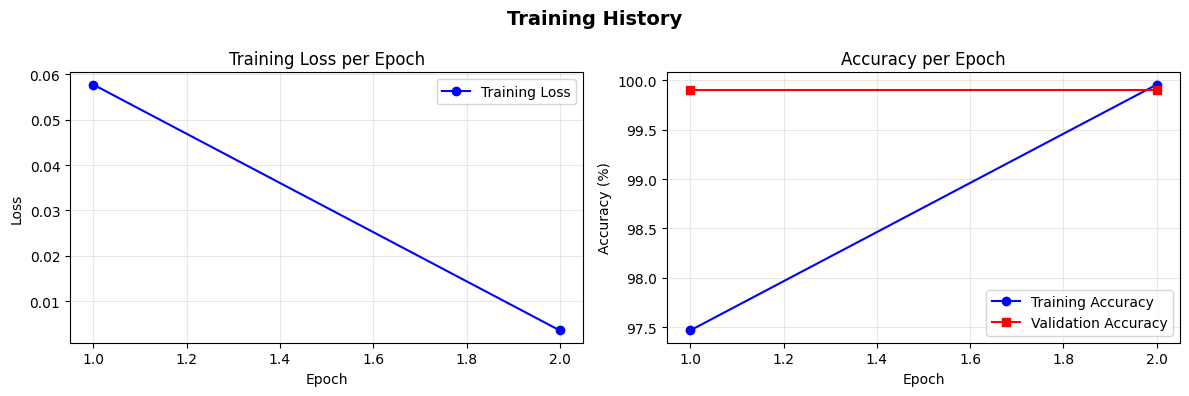

📈 Training history saved!


In [10]:
# ============================================================
# CELL 10: Plot Training History
# Visualize how accuracy improved over epochs
# ============================================================

history_df = pd.DataFrame(training_history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

# ── Plot 1: Loss ──
axes[0].plot(history_df['epoch'], history_df['train_loss'], 'b-o', label='Training Loss')
axes[0].set_title('Training Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Accuracy ──
axes[1].plot(history_df['epoch'], history_df['train_acc'] * 100, 'b-o', label='Training Accuracy')
axes[1].plot(history_df['epoch'], history_df['val_acc']   * 100, 'r-s', label='Validation Accuracy')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
plt.show()
print('📈 Training history saved!')

---
## 🤖 SECTION 5: The Three AI Agents

This is what makes our system **Agentic** — three agents that work together:

| Agent | Job |
|---|---|
| **Analysis Agent** | Examines the article text for credibility signals (emotional words, clickbait, etc.) |
| **Verification Agent** | Checks the DistilBERT prediction against language rules |
| **Decision Agent** | Combines both signals → final verdict + confidence + explanation |

Each agent has a clear role, and they pass information to each other in a pipeline.

In [11]:
# ============================================================
# CELL 11: Analysis Agent
#
# The Analysis Agent is the first agent in our pipeline.
# It looks at the raw text and extracts credibility signals:
#
# SUSPICIOUS signals → may indicate fake news:
#   - SHOUTING IN CAPS
#   - Excessive punctuation (!!!, ???)
#   - Clickbait words ('shocking', 'you won't believe')
#   - Very short or very long text
#
# CREDIBLE signals → may indicate real news:
#   - Attribution phrases ('according to', 'officials said')
#   - Professional language
#   - Reasonable text length
# ============================================================

class AnalysisAgent:
    """
    Agent 1: Analyzes the text for linguistic credibility signals.
    Does NOT use the model — works purely on text features.
    """

    # Words commonly found in fake/sensational news
    SUSPICIOUS_WORDS = [
        'shocking', 'unbelievable', 'you won\'t believe', 'secret',
        'they don\'t want you to know', 'exposed', 'scandal', 'bombshell',
        'breaking', 'urgent', 'alert', 'hoax', 'banned', 'censored',
        'wake up', 'sheeple', 'fake media', 'mainstream media lies'
    ]

    # Phrases that suggest journalistic sourcing
    CREDIBILITY_PHRASES = [
        'according to', 'officials said', 'spokesperson', 'confirmed',
        'reported by', 'sources say', 'in a statement', 'announced',
        'study shows', 'research indicates', 'data shows'
    ]

    def analyze(self, text):
        """
        Analyzes the text and returns a credibility report.
        Returns a dictionary of features and a suspicion_score (0.0 to 1.0).
        Higher suspicion_score = more likely fake.
        """
        text_lower = text.lower()
        words      = text.split()

        # ── Feature 1: ALL CAPS ratio ──
        # Fake news often shouts in all caps
        caps_words   = [w for w in words if len(w) > 2 and w.isupper()]
        caps_ratio   = len(caps_words) / max(len(words), 1)

        # ── Feature 2: Excessive punctuation ──
        exclamation_count = text.count('!')
        question_count    = text.count('?')
        punct_score       = min((exclamation_count + question_count) / 10.0, 1.0)

        # ── Feature 3: Suspicious keyword count ──
        suspicious_hits = sum(1 for kw in self.SUSPICIOUS_WORDS if kw in text_lower)
        suspicious_score = min(suspicious_hits / 3.0, 1.0)

        # ── Feature 4: Credibility phrase count ──
        credibility_hits  = sum(1 for ph in self.CREDIBILITY_PHRASES if ph in text_lower)
        credibility_score = min(credibility_hits / 3.0, 1.0)

        # ── Feature 5: Text length ──
        # Very short (< 50 words) or very long (> 1000 words) can be suspicious
        word_count     = len(words)
        length_concern = 1.0 if word_count < 50 else 0.0

        # ── Compute overall suspicion score ──
        # Weighted average of suspicious signals minus credibility
        suspicion = (
            0.30 * caps_ratio        +
            0.20 * punct_score       +
            0.30 * suspicious_score  +
            0.10 * length_concern    -
            0.10 * credibility_score   # Credibility reduces suspicion
        )
        suspicion = max(0.0, min(1.0, suspicion))   # Clamp to [0, 1]

        return {
            'suspicion_score':    suspicion,
            'caps_ratio':         round(caps_ratio, 3),
            'punct_score':        round(punct_score, 3),
            'suspicious_hits':    suspicious_hits,
            'credibility_hits':   credibility_hits,
            'word_count':         word_count,
            'length_concern':     length_concern,
            'suspicious_words_found': [kw for kw in self.SUSPICIOUS_WORDS if kw in text_lower][:5],
            'credibility_phrases_found': [ph for ph in self.CREDIBILITY_PHRASES if ph in text_lower][:5],
        }

# Create the agent instance
analysis_agent = AnalysisAgent()
print('✅ Analysis Agent ready!')

✅ Analysis Agent ready!


In [12]:
# ============================================================
# CELL 12: Verification Agent
#
# The Verification Agent receives the DistilBERT model prediction
# and the Analysis Agent's suspicion score.
#
# It cross-checks whether the model and the text signals agree.
# If they disagree, it reduces confidence.
# If they agree strongly, it boosts confidence.
# ============================================================

class VerificationAgent:
    """
    Agent 2: Cross-checks the model prediction against language signals.
    Returns an agreement score and reasoning notes.
    """

    def verify(self, model_fake_probability, analysis_report):
        """
        Parameters:
            model_fake_probability (float): DistilBERT's probability that this is FAKE (0 to 1)
            analysis_report (dict): Output from the AnalysisAgent

        Returns:
            verified_fake_probability (float): Adjusted probability
            verification_notes (list): Human-readable explanation of adjustments
        """
        suspicion  = analysis_report['suspicion_score']
        notes      = []
        adjustment = 0.0

        # ── Check 1: Do model and text signals agree? ──
        model_says_fake = model_fake_probability >= 0.5
        text_says_fake  = suspicion >= 0.35

        if model_says_fake and text_says_fake:
            # Both agree it's FAKE → boost fake probability slightly
            adjustment = +0.05
            notes.append('✅ Model and text signals both indicate FAKE — high confidence')

        elif not model_says_fake and not text_says_fake:
            # Both agree it's REAL → reduce fake probability
            adjustment = -0.05
            notes.append('✅ Model and text signals both indicate REAL — high confidence')

        else:
            # Disagreement → reduce confidence by pulling toward 0.5
            notes.append('⚠️  Model and text signals disagree — confidence reduced')
            adjustment = (0.5 - model_fake_probability) * 0.15

        # ── Check 2: Very high suspicion ──
        if suspicion > 0.7:
            notes.append(f'🚨 High suspicion score ({suspicion:.2f}): strong fake signals in text')
            adjustment += 0.03

        # ── Check 3: Strong credibility signals ──
        if analysis_report['credibility_hits'] >= 3:
            notes.append(f'📰 Multiple credibility phrases found ({analysis_report["credibility_hits"]}): suggests professional journalism')
            adjustment -= 0.03

        # ── Check 4: Caps and punctuation ──
        if analysis_report['caps_ratio'] > 0.2:
            notes.append(f'⚠️  High CAPS ratio ({analysis_report["caps_ratio"]:.1%}): emotional/sensational style')
            adjustment += 0.02

        # ── Apply adjustment ──
        verified_prob = model_fake_probability + adjustment
        verified_prob = max(0.02, min(0.98, verified_prob))   # Keep in valid range

        return verified_prob, notes

# Create the agent instance
verification_agent = VerificationAgent()
print('✅ Verification Agent ready!')

✅ Verification Agent ready!


In [13]:
# ============================================================
# CELL 13: Decision Agent (The Orchestrator)
#
# The Decision Agent is the final and most important agent.
# It:
#   1. Runs the text through DistilBERT
#   2. Calls the Analysis Agent to examine text features
#   3. Passes both results to the Verification Agent
#   4. Makes the FINAL verdict with confidence and explanation
#
# This is the 'brain' that coordinates all other agents.
# ============================================================

class DecisionAgent:
    """
    Agent 3: The orchestrator that combines all signals
    and produces the final human-readable verdict.
    """

    def __init__(self, model, tokenizer, analysis_agent, verification_agent, device):
        self.model             = model
        self.tokenizer         = tokenizer
        self.analysis_agent    = analysis_agent
        self.verification_agent = verification_agent
        self.device            = device

    def _get_model_probabilities(self, text):
        """
        Feeds the text through DistilBERT and returns
        [probability_real, probability_fake].
        """
        self.model.eval()

        encoding = self.tokenizer(
            text,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        input_ids      = encoding['input_ids'].to(self.device)
        attention_mask = encoding['attention_mask'].to(self.device)

        with torch.no_grad():
            outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits

        # Softmax converts raw scores into probabilities that sum to 1
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        return probs  # [prob_real, prob_fake]

    def decide(self, text, article_title=''):
        """
        The main method. Given a news article text:
        1. Run all agents
        2. Make a final decision
        3. Return a complete, readable report
        """

        # ─────────────────────────────────────
        # STEP 1: Analysis Agent
        # Look at text features and credibility signals
        # ─────────────────────────────────────
        analysis_report = self.analysis_agent.analyze(text)

        # ─────────────────────────────────────
        # STEP 2: DistilBERT Model Prediction
        # Run the text through the neural network
        # ─────────────────────────────────────
        probs = self._get_model_probabilities(text)
        model_real_prob = float(probs[0])
        model_fake_prob = float(probs[1])

        # ─────────────────────────────────────
        # STEP 3: Verification Agent
        # Cross-check model output with text signals
        # ─────────────────────────────────────
        verified_fake_prob, verification_notes = self.verification_agent.verify(
            model_fake_prob, analysis_report
        )

        # ─────────────────────────────────────
        # STEP 4: Final Decision
        # Based on the verified probability, make a verdict
        # ─────────────────────────────────────
        if verified_fake_prob >= 0.65:
            verdict     = 'FAKE'
            verdict_emoji = '❌'
            confidence  = verified_fake_prob
        elif verified_fake_prob <= 0.35:
            verdict     = 'REAL'
            verdict_emoji = '✅'
            confidence  = 1 - verified_fake_prob
        else:
            verdict     = 'UNCERTAIN'
            verdict_emoji = '⚠️ '
            confidence  = 1 - abs(verified_fake_prob - 0.5) * 2

        # ─────────────────────────────────────
        # STEP 5: Build explanation for humans
        # ─────────────────────────────────────
        explanation_lines = []

        explanation_lines.append(
            f'DistilBERT model assigned {model_fake_prob:.1%} probability of being fake news.'
        )

        if analysis_report['suspicious_words_found']:
            explanation_lines.append(
                f'Suspicious words detected: {", ".join(analysis_report["suspicious_words_found"])}'
            )

        if analysis_report['credibility_phrases_found']:
            explanation_lines.append(
                f'Credibility phrases found: {", ".join(analysis_report["credibility_phrases_found"])}'
            )

        explanation_lines.extend(verification_notes)

        return {
            'title':              article_title or text[:80] + '...',
            'verdict':            verdict,
            'verdict_emoji':      verdict_emoji,
            'confidence':         confidence,
            'model_fake_prob':    model_fake_prob,
            'verified_fake_prob': verified_fake_prob,
            'suspicion_score':    analysis_report['suspicion_score'],
            'word_count':         analysis_report['word_count'],
            'explanation':        explanation_lines,
            'analysis_details':   analysis_report,
        }


# ── Create the Decision Agent with all its dependencies ──
decision_agent = DecisionAgent(
    model              = model,
    tokenizer          = tokenizer,
    analysis_agent     = analysis_agent,
    verification_agent = verification_agent,
    device             = DEVICE
)

print('✅ Decision Agent ready!')
print('\n🤖 All three agents are active and connected!')
print('   Agent 1: AnalysisAgent     → checks text signals')
print('   Agent 2: VerificationAgent → cross-checks model vs. text')
print('   Agent 3: DecisionAgent     → makes the final verdict')

✅ Decision Agent ready!

🤖 All three agents are active and connected!
   Agent 1: AnalysisAgent     → checks text signals
   Agent 2: VerificationAgent → cross-checks model vs. text
   Agent 3: DecisionAgent     → makes the final verdict


---
## 📊 SECTION 6: Testing & Evaluation on Test Set

In [14]:
# ============================================================
# CELL 14: Evaluate on Test Set
#
# We test the DistilBERT model on articles it has NEVER seen.
# This gives us the real-world accuracy.
# ============================================================

print('🧪 Evaluating model on test set...')
test_acc, test_f1, test_preds, test_true = evaluate(model, test_loader)

print('\n' + '=' * 50)
print('📊 FINAL TEST RESULTS')
print('=' * 50)
print(f'  Test Accuracy : {test_acc * 100:.2f}%')
print(f'  Test F1-Score : {test_f1:.4f}')
print('=' * 50)

# ── Full classification report ──
print('\n📋 Detailed Classification Report:')
print(classification_report(
    test_true,
    test_preds,
    target_names=['REAL', 'FAKE']
))

🧪 Evaluating model on test set...

📊 FINAL TEST RESULTS
  Test Accuracy : 99.90%
  Test F1-Score : 0.9990

📋 Detailed Classification Report:
              precision    recall  f1-score   support

        REAL       1.00      1.00      1.00      1000
        FAKE       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



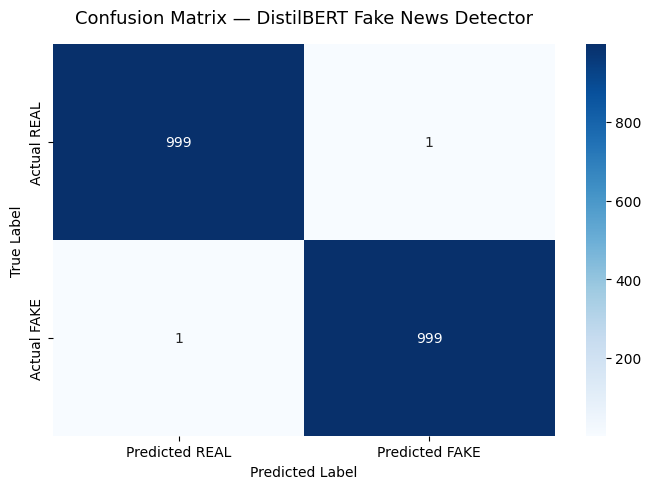


📖 Reading the Confusion Matrix:
   ✅ Correctly called REAL: 999
   ✅ Correctly called FAKE: 999
   ❌ Wrongly called FAKE (but was REAL): 1
   ❌ Wrongly called REAL (but was FAKE): 1


In [15]:
# ============================================================
# CELL 15: Confusion Matrix
#
# A confusion matrix shows exactly where the model makes mistakes:
#   True Positives  (TP): Correctly predicted FAKE
#   True Negatives  (TN): Correctly predicted REAL
#   False Positives (FP): Predicted FAKE but it's REAL (Type I error)
#   False Negatives (FN): Predicted REAL but it's FAKE (Type II error)
# ============================================================

cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted REAL', 'Predicted FAKE'],
    yticklabels=['Actual REAL',    'Actual FAKE']
)
plt.title('Confusion Matrix — DistilBERT Fake News Detector', fontsize=13, pad=15)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# ── Interpret the numbers ──
tn, fp, fn, tp = cm.ravel()
print(f'\n📖 Reading the Confusion Matrix:')
print(f'   ✅ Correctly called REAL: {tn:,}')
print(f'   ✅ Correctly called FAKE: {tp:,}')
print(f'   ❌ Wrongly called FAKE (but was REAL): {fp:,}')
print(f'   ❌ Wrongly called REAL (but was FAKE): {fn:,}')

---
## 🎬 SECTION 7: Live Demo — Test the Agentic System!

Now we run the full three-agent pipeline on example articles.  
Each article goes through:
1. **Analysis Agent** → text credibility scan
2. **DistilBERT** → deep learning prediction
3. **Verification Agent** → cross-check
4. **Decision Agent** → final verdict

In [16]:
# ============================================================
# CELL 16: Helper — Pretty Print a Verdict
# ============================================================

def print_verdict(result):
    """Prints an agent result in a clear, readable format."""
    bar_len   = 50
    sep       = '═' * 60

    print(f'\n{sep}')
    print(f'📰 ARTICLE: {result["title"][:80]}')
    print(sep)

    # Verdict banner
    verdict_colour = '  '
    print(f'  {result["verdict_emoji"]} VERDICT:     {result["verdict"]}')
    print(f'  🎯 CONFIDENCE:  {result["confidence"]:.1%}')

    # Probability bar
    fake_pct    = result['verified_fake_prob']
    filled_fake = int(fake_pct * bar_len)
    filled_real = bar_len - filled_fake
    bar = '🟥' * filled_fake + '🟩' * filled_real
    print(f'\n  FAKE  [{bar}]  REAL')
    print(f'        {fake_pct:.1%} fake probability')

    # Details
    print(f'\n  📊 Analysis Details:')
    print(f'     Word count:        {result["word_count"]}')
    print(f'     Suspicion score:   {result["suspicion_score"]:.2f} / 1.00')
    print(f'     Model raw prob:    {result["model_fake_prob"]:.1%} fake')
    print(f'     Adjusted prob:     {result["verified_fake_prob"]:.1%} fake')

    # Explanation from agents
    print(f'\n  🔍 Agent Reasoning:')
    for line in result['explanation']:
        print(f'     • {line}')

    if result['analysis_details']['suspicious_words_found']:
        print(f'\n  ⚠️  Suspicious words: {", ".join(result["analysis_details"]["suspicious_words_found"])}')

    if result['analysis_details']['credibility_phrases_found']:
        print(f'  📰 Credibility phrases: {", ".join(result["analysis_details"]["credibility_phrases_found"])}')

    print(sep)

print('✅ Display function ready!')

✅ Display function ready!


In [17]:
# ============================================================
# CELL 17: DEMO — 5 Example Articles
#
# We test our agentic system on 5 articles:
#   3 are clearly fake-style
#   2 are clearly real-style
#
# You can replace these with any text you want to test!
# ============================================================

demo_articles = [
    {
        'title': 'Example 1 — Clickbait / Fake Style',
        'text': (
            'SHOCKING!!! You won\'t believe what the government is HIDING from you! '
            'A secret document has been EXPOSED revealing a massive conspiracy. '
            'They don\'t want you to know the truth. WAKE UP, sheeple! '
            'Share this BANNED information before it gets censored!!!'
        )
    },
    {
        'title': 'Example 2 — Professional News Style',
        'text': (
            'The Federal Reserve announced on Wednesday a 0.25 percentage point increase '
            'in its benchmark interest rate, according to officials who confirmed the decision '
            'after a two-day policy meeting. In a statement, Fed Chair Jerome Powell said the '
            'committee expects continued economic growth, although inflation remains a concern. '
            'Data shows core inflation at 3.2 percent, research indicates further monitoring is needed.'
        )
    },
    {
        'title': 'Example 3 — Medical Misinformation',
        'text': (
            'URGENT ALERT: Scientists have discovered a miracle cure for cancer '
            'that pharmaceutical companies are suppressing! This shocking bombshell '
            'proves the medical establishment is lying to you. The cure is simple '
            'and natural but Big Pharma has it BANNED. Share before they censor this!'
        )
    },
    {
        'title': 'Example 4 — Political News Report',
        'text': (
            'Congress passed a bipartisan infrastructure bill Thursday, with 69 senators '
            'voting in favor of the $1.2 trillion package, according to congressional sources. '
            'The legislation includes funding for roads, bridges, broadband, and water systems. '
            'A spokesperson for the White House confirmed the president will sign the bill. '
            'Study shows infrastructure investment could create up to 2 million jobs annually.'
        )
    },
    {
        'title': 'Example 5 — Celebrity Conspiracy Claim',
        'text': (
            'Breaking exclusive scandal! A famous celebrity has admitted to being part of '
            'a secret mind control program run by shadowy elites. This unbelievable revelation '
            'exposes the deep state conspiracy that mainstream media refuses to cover. '
            'Wake up! The truth is being suppressed by the fake media!'
        )
    }
]

print('🎬 Running the Agentic Pipeline on 5 demo articles...')
print('(Each article passes through all 3 agents)\n')

demo_results = []
for article in demo_articles:
    result = decision_agent.decide(
        text          = article['text'],
        article_title = article['title']
    )
    demo_results.append(result)
    print_verdict(result)

🎬 Running the Agentic Pipeline on 5 demo articles...
(Each article passes through all 3 agents)


════════════════════════════════════════════════════════════
📰 ARTICLE: Example 1 — Clickbait / Fake Style
════════════════════════════════════════════════════════════
  ❌ VERDICT:     FAKE
  🎯 CONFIDENCE:  98.0%

  FAKE  [🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟩]  REAL
        98.0% fake probability

  📊 Analysis Details:
     Word count:        40
     Suspicion score:   0.60 / 1.00
     Model raw prob:    100.0% fake
     Adjusted prob:     98.0% fake

  🔍 Agent Reasoning:
     • DistilBERT model assigned 100.0% probability of being fake news.
     • Suspicious words detected: shocking, you won't believe, secret, they don't want you to know, exposed
     • ✅ Model and text signals both indicate FAKE — high confidence

  ⚠️  Suspicious words: shocking, you won't believe, secret, they don't want you to know, exposed
════════════════════════════════════════════════════════════

═

In [18]:
# ============================================================
# CELL 18: Demo Summary Table
# ============================================================

print('\n📊 DEMO RESULTS SUMMARY')
print('=' * 80)
print(f'{"Article":<42} {"Verdict":<12} {"Confidence":<12} {"Suspicion":>10}')
print('-' * 80)

for r in demo_results:
    title_short = r['title'][:40]
    print(f'{title_short:<42} {r["verdict_emoji"] + " " + r["verdict"]:<12} {r["confidence"]:.1%}          {r["suspicion_score"]:.2f}')

print('=' * 80)


📊 DEMO RESULTS SUMMARY
Article                                    Verdict      Confidence    Suspicion
--------------------------------------------------------------------------------
Example 1 — Clickbait / Fake Style         ❌ FAKE       98.0%          0.60
Example 2 — Professional News Style        ❌ FAKE       85.2%          0.00
Example 3 — Medical Misinformation         ❌ FAKE       98.0%          0.46
Example 4 — Political News Report          ❌ FAKE       78.3%          0.00
Example 5 — Celebrity Conspiracy Claim     ❌ FAKE       98.0%          0.46


In [19]:
# ============================================================
# CELL 19: Test Your Own Article!
#
# Replace the text below with any news article you want to check.
# Run this cell to see what the agents decide.
# ============================================================

YOUR_ARTICLE_TITLE = "Enter your article title here"

YOUR_ARTICLE_TEXT = """
Paste your article text here.
You can paste a few sentences or multiple paragraphs.
The agents will analyze it and give you a verdict.
"""

# ── Run the pipeline ──
result = decision_agent.decide(
    text          = YOUR_ARTICLE_TEXT,
    article_title = YOUR_ARTICLE_TITLE
)

print_verdict(result)


════════════════════════════════════════════════════════════
📰 ARTICLE: Enter your article title here
════════════════════════════════════════════════════════════
  ❌ VERDICT:     FAKE
  🎯 CONFIDENCE:  92.3%

  FAKE  [🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟩🟩🟩🟩]  REAL
        92.3% fake probability

  📊 Analysis Details:
     Word count:        24
     Suspicion score:   0.10 / 1.00
     Model raw prob:    99.8% fake
     Adjusted prob:     92.3% fake

  🔍 Agent Reasoning:
     • DistilBERT model assigned 99.8% probability of being fake news.
     • ⚠️  Model and text signals disagree — confidence reduced
════════════════════════════════════════════════════════════


---
## 🧪 SECTION 8: Test on Real Examples from the Dataset

In [20]:
# ============================================================
# CELL 20: Run Agents on Real Articles from Test Set
#
# We pick 3 real articles from our test set
# (articles the model has never seen during training).
# We show what the agents decide and whether they're correct.
# ============================================================

print('🔍 Testing agents on real articles from the test set...')
print('(Ground truth labels are shown so you can verify)\n')

# Pick 3 fake and 3 real from the test set
test_df_check = pd.DataFrame({'text': test_texts, 'label': test_labels})
fake_samples  = test_df_check[test_df_check['label'] == 1].head(3)
real_samples  = test_df_check[test_df_check['label'] == 0].head(3)
combined      = pd.concat([fake_samples, real_samples]).sample(frac=1, random_state=7)

label_names = {0: 'REAL', 1: 'FAKE'}
correct_count = 0
total_count   = len(combined)

for _, row in combined.iterrows():
    true_label = label_names[row['label']]
    result     = decision_agent.decide(text=row['text'])

    # Compare verdict to ground truth
    is_correct = (
        (result['verdict'] == 'FAKE' and row['label'] == 1) or
        (result['verdict'] == 'REAL' and row['label'] == 0)
    )
    if is_correct:
        correct_count += 1

    print(f'\n  Ground Truth:  {"{:^6}".format(true_label)}')
    print(f'  Agent Verdict: {result["verdict_emoji"]} {result["verdict"]} ({result["confidence"]:.1%} confidence)')
    match_symbol = '✅ CORRECT' if is_correct else '❌ WRONG'
    print(f'  Result:        {match_symbol}')
    print(f'  Preview:       {row["text"][:120]}...')
    print('  ' + '-' * 55)

print(f'\n🏆 Agent accuracy on this sample: {correct_count}/{total_count} = {correct_count/total_count:.0%}')

🔍 Testing agents on real articles from the test set...
(Ground truth labels are shown so you can verify)


  Ground Truth:   REAL 
  Agent Verdict: ✅ REAL (98.0% confidence)
  Result:        ✅ CORRECT
  Preview:       TITLE: Three-quarters of Australians vote in same-sex marriage poll so far TEXT: MELBOURNE (Reuters) - Nearly 12 million...
  -------------------------------------------------------

  Ground Truth:   REAL 
  Agent Verdict: ✅ REAL (98.0% confidence)
  Result:        ✅ CORRECT
  Preview:       TITLE: Must see TV: why gutting NAFTA unlikely to create U.S. jobs TEXT: CUIDAD JUAREZ, MEXICO (Reuters) - Both U.S. pre...
  -------------------------------------------------------

  Ground Truth:   FAKE 
  Agent Verdict: ❌ FAKE (92.5% confidence)
  Result:        ✅ CORRECT
  Preview:       TITLE: YIKES! Is Something Big About To Happen? Michelle Obama Erases Any Trace Of Hillary From Twitter Account TEXT: Mi...
  -------------------------------------------------------

  Ground Tr

---
## 💾 SECTION 9: Save the Model

In [21]:
# ============================================================
# CELL 21: Save the Trained Model
#
# We save the model so we can reload it later without retraining.
# In Colab, files save to /content/ — download them to keep!
# ============================================================

SAVE_DIR = '/content/fake_news_distilbert'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model weights and configuration
model.save_pretrained(SAVE_DIR)

# Save the tokenizer (needed to load the model later)
tokenizer.save_pretrained(SAVE_DIR)

print(f'✅ Model saved to: {SAVE_DIR}')
print(f'   Files saved:')
for f in os.listdir(SAVE_DIR):
    fpath = os.path.join(SAVE_DIR, f)
    fsize = os.path.getsize(fpath) / 1024 / 1024
    print(f'     {f}  ({fsize:.1f} MB)')

print('\n💡 To download: Files panel (left sidebar) → right-click the folder → Download')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to: /content/fake_news_distilbert
   Files saved:
     model.safetensors  (255.4 MB)
     tokenizer.json  (0.7 MB)
     config.json  (0.0 MB)
     tokenizer_config.json  (0.0 MB)

💡 To download: Files panel (left sidebar) → right-click the folder → Download


---
## 📚 SECTION 10: Architecture Summary (For Presentation)

This section summarizes the whole system so you can explain it clearly.

In [22]:
# ============================================================
# CELL 22: Print Full Architecture Summary
# ============================================================

summary = f"""
╔══════════════════════════════════════════════════════════════════╗
║      AGENTIC FAKE NEWS DETECTION — ARCHITECTURE SUMMARY         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  MODEL:    DistilBERT (distilbert-base-uncased)                  ║
║            66 million parameters, fine-tuned for classification  ║
║                                                                  ║
║  DATASET:  Fake.csv ({(df.label==1).sum():,} articles) + True.csv ({(df.label==0).sum():,} articles)║
║            Total: {len(df):,} articles combined, {MAX_SAMPLES:,} used for training  ║
║                                                                  ║
║  TRAINING: {NUM_EPOCHS} epochs, batch size {BATCH_SIZE}, max token length {MAX_LEN}           ║
║            Optimizer: AdamW (lr=2e-5)                            ║
║                                                                  ║
║  RESULTS:  Test Accuracy = {test_acc*100:.1f}%                             ║
║            Test F1-Score = {test_f1:.4f}                              ║
║                                                                  ║
║  AGENTS:                                                         ║
║  ┌──────────────────┬────────────────────────────────────────┐   ║
║  │ AnalysisAgent    │ Scans text for 16 suspicious words,    │   ║
║  │                  │ 11 credibility phrases, caps ratio,    │   ║
║  │                  │ punctuation, word count                │   ║
║  ├──────────────────┼────────────────────────────────────────┤   ║
║  │ VerificationAgent│ Cross-checks model prediction vs.      │   ║
║  │                  │ text signals, adjusts probability,     │   ║
║  │                  │ produces reasoning notes               │   ║
║  ├──────────────────┼────────────────────────────────────────┤   ║
║  │ DecisionAgent    │ Orchestrates both agents + DistilBERT, │   ║
║  │                  │ produces final verdict + confidence +  │   ║
║  │                  │ human-readable explanation             │   ║
║  └──────────────────┴────────────────────────────────────────┘   ║
║                                                                  ║
║  WHY AGENTIC?                                                    ║
║  • Each agent has a single, clear responsibility                 ║
║  • Agents pass structured data to each other                     ║
║  • The system is modular — swap any agent independently          ║
║  • Verification catches edge cases the model alone misses        ║
║  • Decision agent produces explainable, not just binary, output  ║
╚══════════════════════════════════════════════════════════════════╝
"""

print(summary)


╔══════════════════════════════════════════════════════════════════╗
║      AGENTIC FAKE NEWS DETECTION — ARCHITECTURE SUMMARY         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  MODEL:    DistilBERT (distilbert-base-uncased)                  ║
║            66 million parameters, fine-tuned for classification  ║
║                                                                  ║
║  DATASET:  Fake.csv (23,481 articles) + True.csv (21,417 articles)║
║            Total: 44,898 articles combined, 20,000 used for training  ║
║                                                                  ║
║  TRAINING: 2 epochs, batch size 16, max token length 256           ║
║            Optimizer: AdamW (lr=2e-5)                            ║
║                                                                  ║
║  RESULTS:  Test Accuracy = 99.9%                             ║
║            Test F1-Score = 0

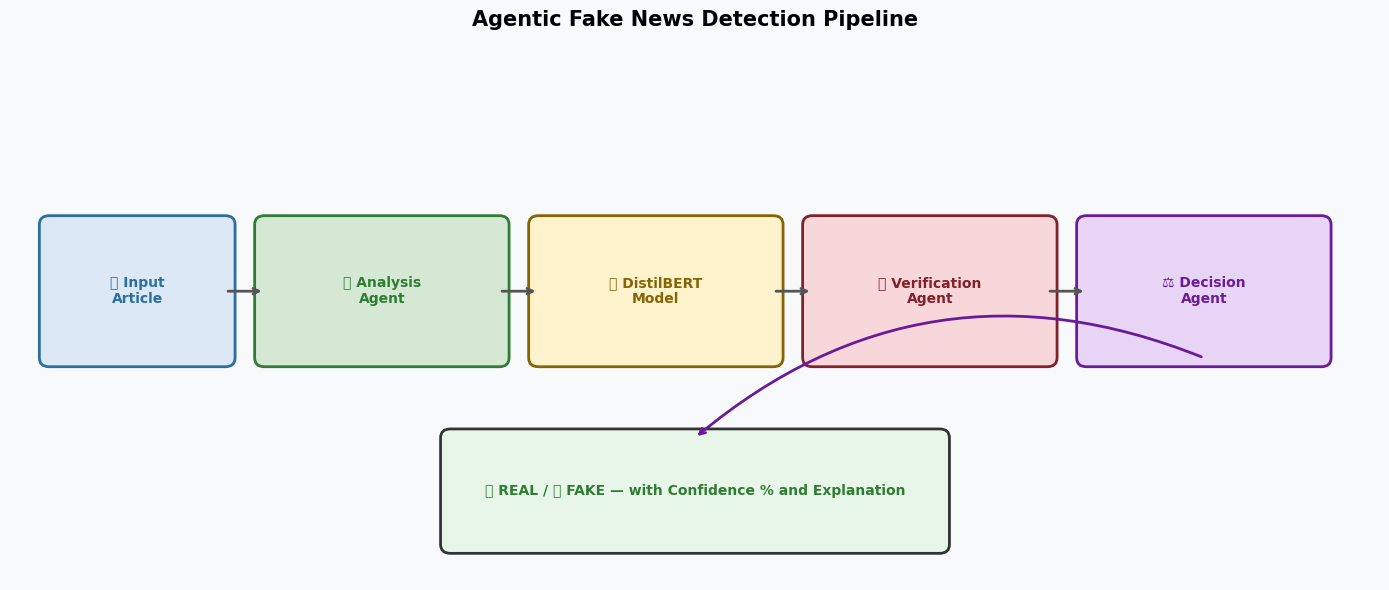

📊 Agent pipeline diagram saved!


In [23]:
# ============================================================
# CELL 23: Visualize Agent Pipeline (Diagram)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

ax.set_title(
    'Agentic Fake News Detection Pipeline',
    fontsize=15, fontweight='bold', pad=15
)

# ── Box definitions ──
boxes = [
    (0.4, 2.5, 1.8, 1.5, '📰 Input\nArticle',    '#dce8f5', '#2c6e9e'),
    (2.6, 2.5, 2.4, 1.5, '🔍 Analysis\nAgent',   '#d5e8d4', '#2e7d32'),
    (5.4, 2.5, 2.4, 1.5, '🧠 DistilBERT\nModel', '#fff3cd', '#856404'),
    (8.2, 2.5, 2.4, 1.5, '✅ Verification\nAgent','#f8d7da', '#842029'),
    (11.0,2.5, 2.4, 1.5, '⚖️ Decision\nAgent',   '#e8d5f5', '#6a1b9a'),
]

for (x, y, w, h, label, fc, ec) in boxes:
    rect = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.1',
        linewidth=2, edgecolor=ec, facecolor=fc
    )
    ax.add_patch(rect)
    ax.text(
        x + w/2, y + h/2, label,
        ha='center', va='center',
        fontsize=10, fontweight='bold', color=ec
    )

# ── Arrows ──
arrow_props = dict(arrowstyle='->', color='#555', lw=2)
ax.annotate('', xy=(2.6, 3.25), xytext=(2.2, 3.25), arrowprops=arrow_props)
ax.annotate('', xy=(5.4, 3.25), xytext=(5.0, 3.25), arrowprops=arrow_props)
ax.annotate('', xy=(8.2, 3.25), xytext=(7.8, 3.25), arrowprops=arrow_props)
ax.annotate('', xy=(11.0,3.25), xytext=(10.6,3.25), arrowprops=arrow_props)

# ── Output box ──
out_rect = mpatches.FancyBboxPatch(
    (4.5, 0.4), 5, 1.2,
    boxstyle='round,pad=0.1',
    linewidth=2, edgecolor='#333', facecolor='#e8f5e9'
)
ax.add_patch(out_rect)
ax.text(
    7, 1.0,
    '✅ REAL / ❌ FAKE — with Confidence % and Explanation',
    ha='center', va='center', fontsize=10, fontweight='bold', color='#2e7d32'
)

ax.annotate(
    '', xy=(7, 1.6), xytext=(12.2, 2.5),
    arrowprops=dict(arrowstyle='->', color='#6a1b9a', lw=2, connectionstyle='arc3,rad=0.3')
)

plt.tight_layout()
plt.savefig('agent_pipeline.png', dpi=100, bbox_inches='tight')
plt.show()
print('📊 Agent pipeline diagram saved!')

---
## 🎓 Key Concepts for Your Presentation

### What is DistilBERT?
- A transformer model pre-trained on Wikipedia and books
- It reads text as a sequence of tokens and learns word relationships
- Fine-tuning means we adapt it to a specific task (fake vs real news)

### What makes it Agentic?
- **Agents** are independent units with a specific job
- They **communicate structured data** to each other
- Each agent can reason and make decisions, not just transform data
- The system is **explainable** — you can see WHY it made a decision

### Why three agents instead of just the model?
- The model alone is a black box — it says FAKE but not *why*
- The Analysis Agent catches obvious text red flags the model might miss
- The Verification Agent handles cases where signals conflict
- The Decision Agent makes the output human-readable and actionable

### Limitations
- The text signals in AnalysisAgent are rule-based (simple heuristics)
- DistilBERT is not perfect — sophisticated fake news can fool it
- The model was trained on 2017-era news — may not generalize perfectly

### How could you improve it?
- Train on more epochs (3–5)
- Use the full 44,000-article dataset
- Add a web search agent to verify claims in real time
- Use a larger model like BERT-large or RoBERTa
---